In [53]:
"""Settings related to escape pattern analysis."""
Path = r'Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\replay\replay_SS_decoder\SSdecoder_cc0081bb96c94e52_data.npz'


In [54]:
"""Imports"""

%load_ext autoreload
%autoreload 2
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
np.warnings = warnings

from replay_trajectory_classification import SortedSpikesDecoder, Environment
from replay_trajectory_classification.continuous_state_transitions import (
    RandomWalk, 
    estimate_movement_var
)

import sys
sys.path.append(r"c:\Users\Jasmine\Documents\GitHub\JAL2_subgoal_pipeline")
from behave_analysis.analyze.Replay.SSdecoder_utils import predicted_position_2d, compute_rmse, gaussian_smooth_rates
from behave_analysis.analyze.Replay.SSdecode_plotting import heatmap_neural_data, plot_predicted_vs_actual_2dpos, plot_behavioral_vars
from behave_analysis.utils.arena_plotting import Arena

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
"""Load data and set paths"""
settings_file = Path.replace('_data.npz', '_settings.npz')
save_file = Path.replace('_data.npz', '_results.npz')
database_path = "\\".join(Path.split('\\')[:-1]) + "\\replay_results.csv"
database = pd.read_csv(database_path)
hexname = Path.split("\\")[-1].split("_")[1]
# find row in database corresponding to this run
database_row = database[database['name'] == hexname]

data = np.load(Path, allow_pickle=True)
settings = np.load(settings_file, allow_pickle=True)

# check if a file with saved results already exists, if so, load it
try:
    results = np.load(save_file, allow_pickle=True)
    print("Loaded existing results from file.")
except FileNotFoundError:
    print("No existing results file found. Please compute results and save to file.")

database_row

Loaded existing results from file.


,name,replay_cells,replay_search_window,replay_decoder_variable,replay_train_condition,replay_test_condition,replay_decoder_train_time_period,replay_decoder_test_time_period,replay_rank_order_corr_method,replay_occupancy_prior,...,replay_state_space_decoder_bin_size,stim_type,redo_compute,cluster_type,show_plots,condition_types,compartment_split,parallel_pool_linshit,replay_template_variable,data_vars
4,cc0081bb96c94e52,all,500,2D_position,barrier_pre_flip,barrier_pre_flip,explore,homing&escape,first_activity,uniform,...,0.001,audio,True,good,False,experimental_conditions,['all'],True,escape,"['train_spikes', 'train_time', 'train_mask', '..."


In [56]:
# set up parameters for decoder
sampling_frequency = 1000 / settings['replay_state_space_decoder_bin_size'] # in Hz, bin_width is in ms
test_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(data['test_segments']) == 1)[0]+1))
test_position_offsets = np.concatenate((test_position_onsets[1:], [len(data['test_segments'])-1]))
train_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(data['train_segments']) == 1)[0]+1))
train_position_offsets = np.concatenate((train_position_onsets[1:], [len(data['train_segments'])-1]))

# set up environment parameters
nbins = np.unique(data['train_position'])

# estimate movement variance from training data, hasn't worked well for me
# movement_vars = []
# for idx, (start, end) in enumerate(zip(train_position_onsets, train_position_offsets)):
#     trial_var = estimate_movement_var(
#         data['train_position'][start:end],  # shape (n_time, 2) for 2D
#         sampling_frequency=sampling_frequency  # e.g., 30 Hz
#     )
#     movement_vars.append(trial_var)
# movement_var = np.median(movement_vars, axis = 0)
# print(f"Estimated movement variance: {movement_var}")

env_2D = Environment(place_bin_size=1,  # For binned data use 1, Adjust based on your actual bin size
                    position_range=[(0, len(nbins)), (0, len(nbins))],  # 0 to 100% of escape route
                    infer_track_interior=False,  # Data is already binned
                    fill_holes=False,
                    dilate=False,
                    bin_count_threshold=1)

transition_type = RandomWalk(movement_var=1,# move about 1 bin per time step!
                             use_diffusion=True) # IMPORTANT: Respects 2D geometry/boundaries

decoder = SortedSpikesDecoder(environment=env_2D,
                              sorted_spikes_algorithm='spiking_likelihood_kde',
                              sorted_spikes_algorithm_params={'block_size': None,
                                                            'position_std': 1.0,
                                                            'use_diffusion': False})

"""plain vanilla use of trianing data"""
if data['train_spikes'].shape[0] == data['train_position'].shape[0]:
    train_spikes = data['train_spikes']
    test_spikes = data['test_spikes']
if data['train_spikes'].shape[1] == data['train_position'].shape[0]:
    train_spikes = data['train_spikes'].T
    test_spikes = data['test_spikes'].T
s = time.time()
decoder.fit(data['train_position'], train_spikes)
train = time.time()
print(f"Training time: {(train - s)/60:.2f} minutes")

test_time = np.arange(0, data['test_time'].shape[0] / (1 / 0.001), 0.001)
for idx, (start, end) in enumerate(zip(test_position_onsets, test_position_offsets)):
    print(f"Predicting test data for segment {idx+1}/{len(test_position_onsets)}...")
    test_results = decoder.predict(test_spikes[start:end], time=test_time[start:end])
    if idx == 0:
        test_res = np.array(test_results.causal_posterior)
    else:
        test_res = np.concatenate((test_res, np.array(test_results.causal_posterior)), axis=0)
pred_test = time.time()
print(f"Test prediction time: {(pred_test - train)/60:.2f} minutes")

train_time = np.arange(0, data['train_time'].shape[0] / (1 / 0.001), 0.001)
for idx, (start, end) in enumerate(zip(train_position_onsets, train_position_offsets)):
    print(f"Predicting training data for segment {idx+1}/{len(train_position_onsets)}...")
    train_results = decoder.predict(train_spikes[start:end], time=train_time[start:end])
    if idx == 0:
        train_res = np.array(train_results.causal_posterior)
    else:
        train_res = np.concatenate((train_res, np.array(train_results.causal_posterior)), axis=0)
pred_train = time.time()
print(f"Train prediction time: {(pred_train - pred_test)/60:.2f} minutes")

Training time: 9.73 minutes
Predicting test data for segment 1/76...


100%|██████████| 274/274 [00:15<00:00, 17.77it/s]


Predicting test data for segment 2/76...


100%|██████████| 274/274 [00:15<00:00, 17.76it/s]


Predicting test data for segment 3/76...


...

Predicting training data for segment 75/76...


100%|██████████| 274/274 [00:31<00:00,  8.74it/s]


Predicting training data for segment 76/76...


100%|██████████| 274/274 [00:16<00:00, 16.82it/s]


Train prediction time: 324.89 minutes


In [74]:
"""Compute predicted position for train and test data"""

bin_centers = decoder.environment.place_bin_centers_
test_predicted = predicted_position_2d(test_res, bin_centers, method= 'argmax')

train_predicted = predicted_position_2d(train_res, bin_centers, method= 'argmax')

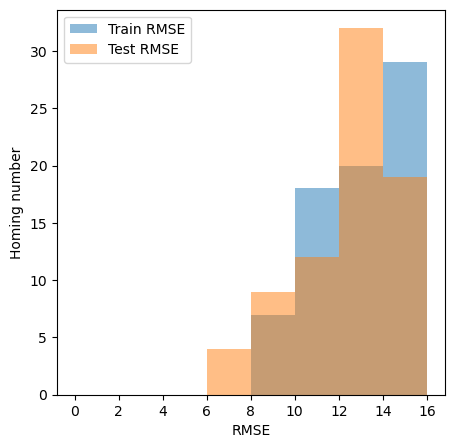

In [58]:
"""Compute RMSE for train and test data predictions"""

# test data
test_rmse = np.zeros(len(test_position_onsets))
for idx in range(len(test_position_onsets)):
    actual_position = data['test_position'][test_position_onsets[idx]:test_position_offsets[idx]]
    test_predicted_position = test_predicted[test_position_onsets[idx]:test_position_offsets[idx]]
    # Direct Euclidean distance
    test_rmse[idx] = compute_rmse(test_predicted_position, actual_position)

# train_data

train_rmse = np.zeros(len(train_position_onsets))
for idx in range(len(train_position_onsets)):
    actual_position = data['train_position'][train_position_onsets[idx]:train_position_offsets[idx]]
    train_predicted_position = train_predicted[train_position_onsets[idx]:train_position_offsets[idx]]
    # Direct Euclidean distance
    train_rmse[idx] = compute_rmse(train_predicted_position, actual_position)

bins = np.arange(0, max(max(train_rmse), max(test_rmse)) + 1, 2)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(train_rmse, bins = bins, alpha=0.5, label='Train RMSE')
axs.hist(test_rmse, bins = bins, alpha=0.5, label='Test RMSE')
axs.set_xlabel('RMSE')
axs.set_ylabel('Homing number')
axs.legend()

# save results

np.savez(save_file,
         test_causal_posterior=test_results.causal_posterior,
         test_acausal_posterior=test_results.acausal_posterior,
         train_causal_posterior=train_results.causal_posterior,
         train_acausal_posterior=train_results.acausal_posterior,
         bin_centers=bin_centers,)

In [ ]:
# load behavior data, filter with test mask, plot the trjectories and see what the mouse was actually doing!
video_path = Path.split("models")[0] + "full_video_dataframe.csv"
vdf = pd.read_csv(video_path)
test_frame_onsets = np.where(np.diff(data['test_mask'].astype(int))>0)[0] + 1
test_frame_offsets = np.where(np.diff(data['test_mask'].astype(int))<0)[0] + 1
train_frame_onsets = np.where(np.diff(data['train_mask'].astype(int))>0)[0] + 1
train_frame_offsets = np.where(np.diff(data['train_mask'].astype(int))<0)[0] + 1

arena_radius=460
bin_size = (arena_radius*2) / settings['ep_bins'] 

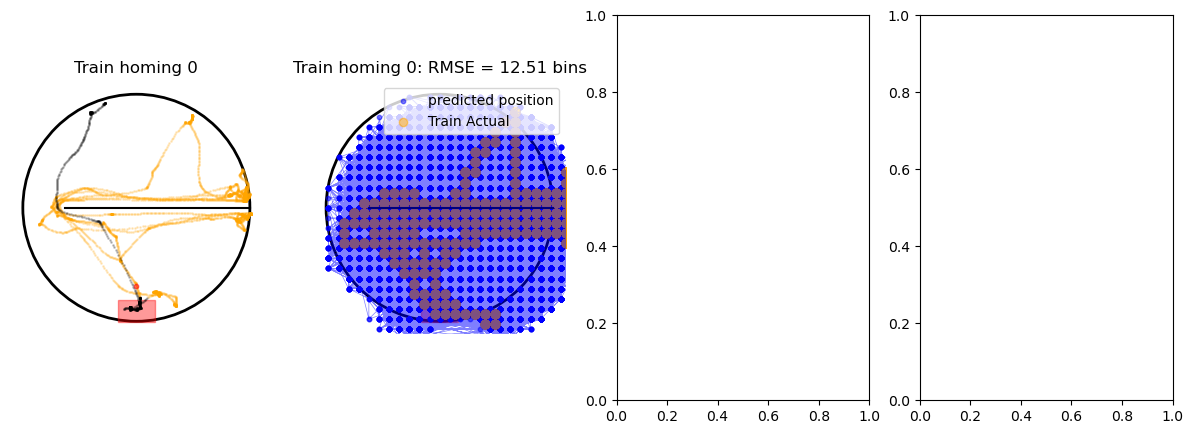

In [63]:
"""Plot for individual train data homings!
Compare behavior to the actual and decoder-predicted fraction of escape route!"""
from behave_analysis.analyze.Replay.SSdecode_plotting import plot_mouse_behaviour
idx = 0
time_marker = [.5]

fig, ax = plt.subplots(1, 4, figsize = (15, 5))
plot_mouse_behaviour(ax[0],
                     x = vdf['mouse_x_position'].to_numpy(),
                     y = vdf['mouse_y_position'].to_numpy(),
                     onset = train_frame_onsets[idx],
                     offset = train_frame_offsets[idx],
                     condition = settings['replay_train_condition'],
                     barrier_coordinates = settings['barrier_train_location'] if 'barrier' in str(settings['replay_train_condition']) else None,
                     time_markers = [int(t*40) for t in time_marker],
                     look_back = 200,
                     look_forward = 400,
                     title = f"Train homing {idx}")

plot_predicted_vs_actual_2dpos(ax[1],
                              predicted_position = train_predicted[train_position_onsets[idx]:train_position_offsets[idx],:],
                              actual_position = data['train_position'][train_position_onsets[idx]:train_position_offsets[idx],:],
                              dim = settings['ep_bins'],
                              condition=settings['replay_train_condition'],
                              barrier_coordinates=settings['barrier_train_location'],
                              title = f"Train homing {idx}: RMSE = {train_rmse[idx]:.2f} bins")

# train_time_slice = train_time[train_position_onsets[idx]:train_position_offsets[idx]] - train_time[train_position_onsets[idx]] # so that it starts at 0! 
# rates = gaussian_smooth_rates(data['train_spikes'][train_position_onsets[idx]:train_position_offsets[idx], data['template_seq']],
#                               sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
# z_rates = zscore(rates, axis=0)
# heatmap_neural_data(ax[2], z_rates.T, train_time_slice, time_marker)

# plot_behavioral_vars(axs = ax[3], time = np.arange(len(vdf['speed'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]])) / 40,
#                     y = vdf['speed'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]], 
#                     color='g', ylabel = 'Speed', time_markers = time_marker, xlabel = 'Time (s)')

# plot_behavioral_vars(axs = ax[3].twinx(), time = np.arange(len(vdf['hdir'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]-1])) / 40,
#                     y = np.diff(np.rad2deg(vdf['hdir'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]])), 
#                     color='m', ylabel = 'Delta hdir(degrees)', xlabel = 'Time (s)')

# fig.tight_layout()

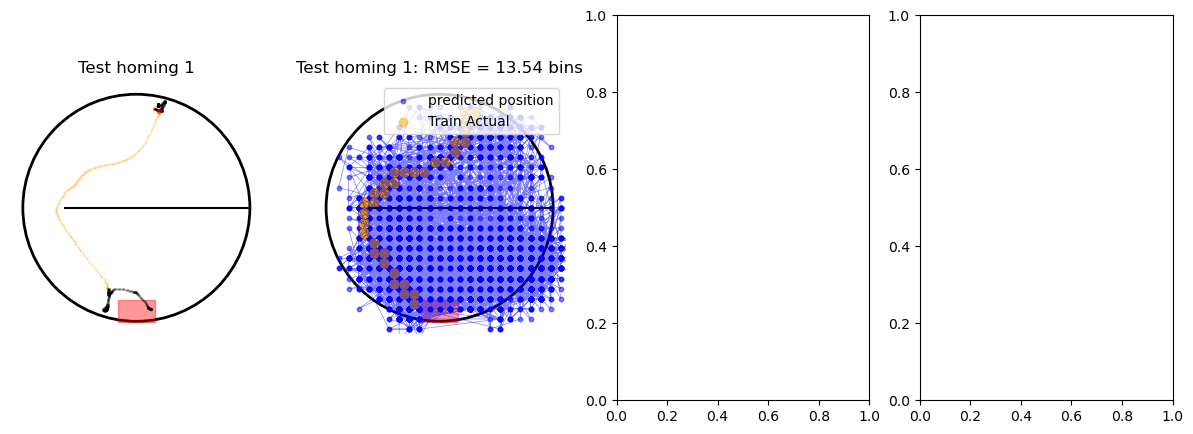

In [65]:
"""Plot for individual test data homings!
Compare behavior to the actual and decoder-predicted fraction of escape route!"""
idx = 1
time_marker = [.5]

fig, ax = plt.subplots(1, 4, figsize = (15, 5))
plot_mouse_behaviour(ax[0],
                     x = vdf['mouse_x_position'].to_numpy(),
                     y = vdf['mouse_y_position'].to_numpy(),
                     onset = test_frame_onsets[idx],
                     offset = test_frame_offsets[idx],
                     condition = settings['replay_test_condition'],
                     barrier_coordinates = settings['barrier_test_location'] if 'barrier' in str(settings['replay_test_condition']) else None,
                     time_markers = [int(t*40) for t in time_marker],
                     look_back = 200,
                     look_forward = 400,
                     title = f"Test homing {idx}")

plot_predicted_vs_actual_2dpos(ax[1],
                              predicted_position = test_predicted[test_position_onsets[idx]:test_position_offsets[idx],:],
                              actual_position = data['test_position'][test_position_onsets[idx]:test_position_offsets[idx],:],
                              dim = settings['ep_bins'],
                              condition=settings['replay_test_condition'],
                              barrier_coordinates=settings['barrier_test_location'],
                              title = f"Test homing {idx}: RMSE = {test_rmse[idx]:.2f} bins")

# test_time_slice = test_time[test_position_onsets[idx]:test_position_offsets[idx]] - test_time[test_position_onsets[idx]] # so that it starts at 0! 
# rates = gaussian_smooth_rates(data['test_spikes'][test_position_onsets[idx]:test_position_offsets[idx], data['template_seq']],
#                               sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
# z_rates = zscore(rates, axis=0)
# heatmap_neural_data(ax[2], z_rates.T, test_time_slice, time_marker)

# plot_behavioral_vars(axs = ax[3], time = np.arange(len(vdf['speed'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]])) / 40,
#                     y = vdf['speed'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]], 
#                     color='g', ylabel = 'Speed', time_markers = time_marker, xlabel = 'Time (s)')

# plot_behavioral_vars(axs = ax[3].twinx(), time = np.arange(len(vdf['hdir'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]-1])) / 40,
#                     y = np.diff(np.rad2deg(vdf['hdir'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]])), 
#                     color='m', ylabel = 'Delta hdir(degrees)', xlabel = 'Time (s)')

# fig.tight_layout()

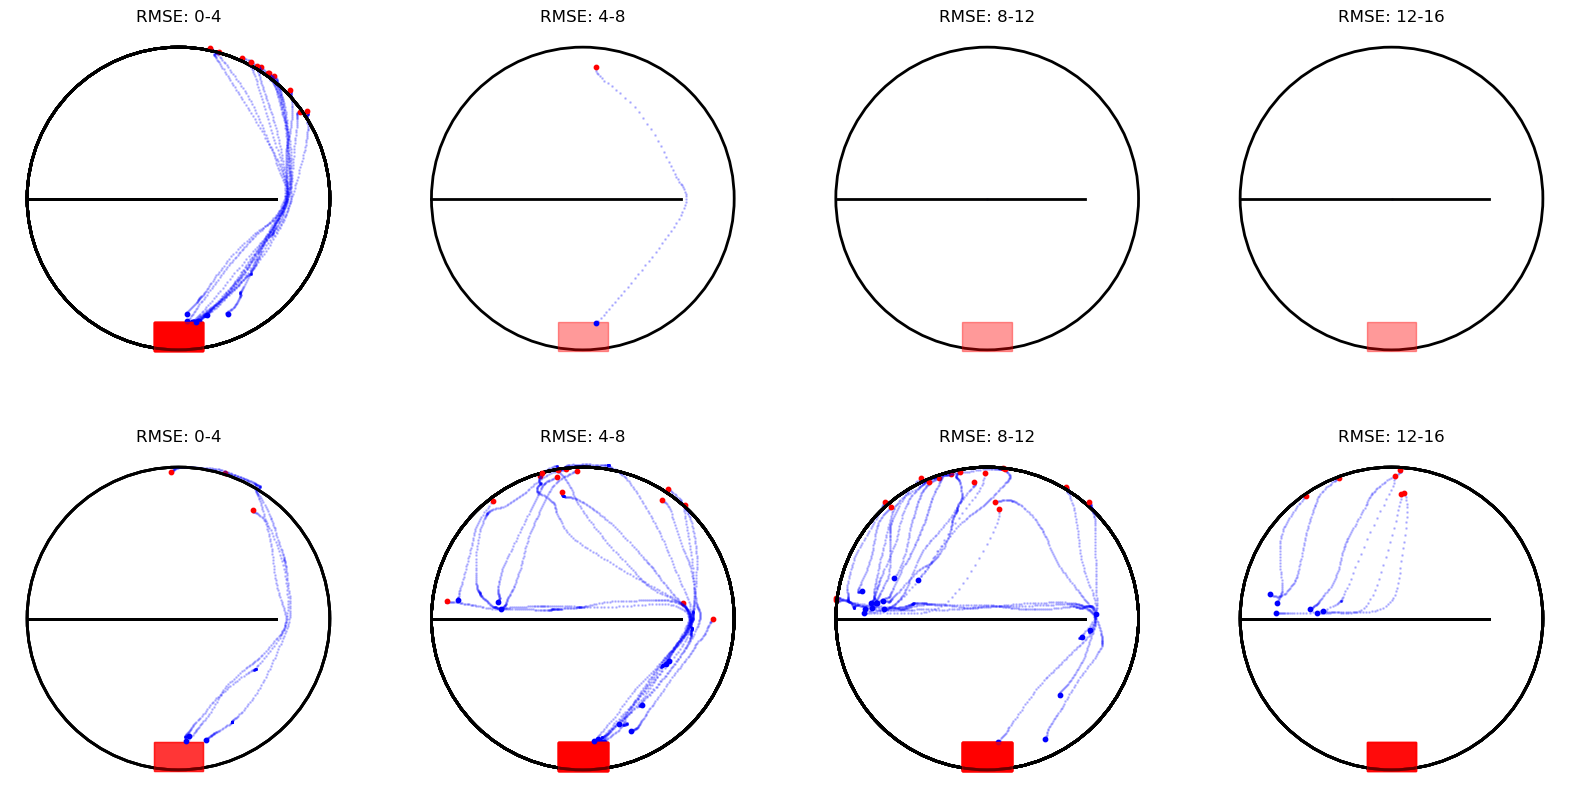

In [438]:
"""Look at homing behavior for different RMSE values"""
rmse_thresholds = [0, 4, 8, 12, 16]

fig, axs = plt.subplots(2, len(rmse_thresholds)-1, figsize=(5*(len(rmse_thresholds)-1), 10))
for t in range(len(rmse_thresholds)-1):
    # plot train behavior
    idx = np.where((train_rmse >= rmse_thresholds[t]) & (train_rmse < rmse_thresholds[t+1]))[0]

    axs[0, t].set_title(f"RMSE: {rmse_thresholds[t]}-{rmse_thresholds[t+1]}")
    for i in idx:
        trajectory_plot(axs[0, t], vdf['mouse_x_position'].to_numpy()[train_frame_onsets[i]:train_frame_offsets[i]],
                        vdf['mouse_y_position'].to_numpy()[train_frame_onsets[i]:train_frame_offsets[i]], settings['replay_train_condition'], settings['barrier_train_location'])
        axs[0, t].scatter(vdf['mouse_x_position'].to_numpy()[train_frame_onsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[train_frame_onsets[i]], color='red', s=10)
        axs[0, t].scatter(vdf['mouse_x_position'].to_numpy()[train_frame_offsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[train_frame_offsets[i]], color='blue', s=10)
    if len(idx) == 0:
        trajectory_plot(axs[0, t], [512,512], [512,512], settings['replay_train_condition'], settings['barrier_train_location'])

    # plot test behavior
    idx = np.where((test_rmse >= rmse_thresholds[t]) & (test_rmse < rmse_thresholds[t+1]))[0]

    axs[1, t].set_title(f"RMSE: {rmse_thresholds[t]}-{rmse_thresholds[t+1]}")
    for i in idx:
        trajectory_plot(axs[1, t], vdf['mouse_x_position'].to_numpy()[test_frame_onsets[i]:test_frame_offsets[i]],
                        vdf['mouse_y_position'].to_numpy()[test_frame_onsets[i]:test_frame_offsets[i]], settings['replay_test_condition'], settings['barrier_test_location'])
        axs[1, t].scatter(vdf['mouse_x_position'].to_numpy()[test_frame_onsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[test_frame_onsets[i]], color='red', s=10)
        axs[1, t].scatter(vdf['mouse_x_position'].to_numpy()[test_frame_offsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[test_frame_offsets[i]], color='blue', s=10)
    if len(idx) == 0:
        trajectory_plot(axs[1, t], [512,512], [512,512], settings['replay_test_condition'], settings['barrier_test_location'])

In [ ]:
"""Look at the actual and decoder tuning curves"""
# TODO: need to load the tuning curves!!
# g = (decoder.place_fields_ * sampling_frequency).plot(
#         x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
# g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
# for ax, place_field in zip(g.axes.flat, tuning_curves):
#     ax.plot(np.arange(25), place_field, linewidth=2, color="black", zorder=-1, label="True")
# sns.despine()